In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [8]:
cd_pvs = pd.read_csv('data/brr_jama-im/data/cd_pvs.csv')
md_donors = pd.read_csv('data/brr_jama-im/data/md_donors.csv')

/var/folders/y2/820f0d093ps3xgsy472nf3zc0000gn/T/ipykernel_67961/3098644720.py:2: DtypeWarning: Columns (0: business_address, 1: business_address2, 2: business_city, 3: business_state, 4: business_zipcode, 5: parent_org, 6: taxonomy1, 7: taxonomy2, 8: taxonomy3) have mixed types. Specify dtype option on import or set low_memory=False.
  md_donors = pd.read_csv('data/brr_jama-im/data/md_donors.csv')
/var/folders/y2/820f0d093ps3xgsy472nf3zc0000gn/T/ipykernel_67961/3098644720.py:3: DtypeWarning: Columns (0: title, 1: party, 2: district, 3: distcyc, 4: ico.status, 5: pwinner, 6: gwinner, 7: s.elec.stat, 8: r.elec.stat, 9: fec.cand.status, 10: igcat, 11: comtype, 12: FEC.ID, 13: NID, 14: party.orig, 15: nimsp.party, 16: nimsp.candidate.ICO.code, 17: nimsp.district, 18: nimsp.candidate.status) have mixed types. Specify dtype option on import or set low_memory=False.
  recipients_1979_2024 = pd.read_csv('data/dime_recipients_1979_2024.csv')


In [42]:
identified_md_donors = md_donors['bonica_cid'].dropna().unique()

print(f"Identified {len(identified_md_donors)} unique medical doctor donor IDs.")

Identified 256226 unique medical doctor donor IDs.


In [10]:
contrib_2008 = pd.read_csv('data/contribDB_2008.csv')

/var/folders/y2/820f0d093ps3xgsy472nf3zc0000gn/T/ipykernel_67961/2095064136.py:1: DtypeWarning: Columns (0: transaction.type, 1: contributor.lname, 2: contributor.fname, 3: contributor.mname, 4: contributor.suffix, 5: contributor.title, 6: contributor.ffname, 7: contributor.zipcode, 8: contributor.occupation, 9: contributor.employer, 10: occ.standardized, 11: is.corp, 12: recipient.party, 13: election.type, 14: latitude, 15: longitude, 16: censustract, 17: efec.memo, 18: efec.transaction.id.orig, 19: bk.ref.transaction.id, 20: efec.org.orig, 21: efec.comid.orig, 22: efec.form.type) have mixed types. Specify dtype option on import or set low_memory=False.
  contrib_2008 = pd.read_csv('data/contribDB_2008.csv')


In [21]:
for c in contrib_2008.columns:
    print(c)   

cycle
transaction.id
transaction.type
amount
date
bonica.cid
contributor.name
contributor.lname
contributor.fname
contributor.mname
contributor.suffix
contributor.title
contributor.ffname
contributor.type
contributor.gender
contributor.address
contributor.city
contributor.state
contributor.zipcode
contributor.occupation
contributor.employer
occ.standardized
is.corp
recipient.name
bonica.rid
recipient.party
recipient.type
recipient.state
seat
election.type
latitude
longitude
gis.confidence
contributor.district
censustract
efec.memo
efec.memo2
efec.transaction.id.orig
bk.ref.transaction.id
efec.org.orig
efec.comid.orig
efec.form.type
excluded.from.scaling
contributor.cfscore
candidate.cfscore


In [129]:
# Drop rows with negative or NaN contribution amounts
contrib_2008 = contrib_2008[contrib_2008['amount'] > 0].dropna(subset=['amount'])

# Convert recipient.party to float
contrib_2008['recipient.party'] = pd.to_numeric(contrib_2008['recipient.party'], errors='coerce')

# For each candidate (bonica.rid), create df with total contributions by donor (cfdb_donor_id)
contrib_by_candidate_name_grp = contrib_2008.groupby(['bonica.rid', 'recipient.name', 'recipient.party', 'recipient.type', 'recipient.state',
                                             'seat', 'election.type', 'candidate.cfscore'])['amount'].sum().reset_index()

# Sum now across candidate name and election type (general vs. primary)
contrib_by_candidate = contrib_2008.groupby(['bonica.rid', 'recipient.party', 'recipient.type', 'recipient.state',
                                                             'seat', 'candidate.cfscore'])['amount'].sum().reset_index()
print(f"Found {len(contrib_by_candidate)} unique candidates by bonica_rid and chars other than name in contrib_2008.")

# Aggregate only by bonica.rid to get total contributions per candidate
cand_contrib_rid = contrib_2008.groupby('bonica.rid')['amount'].sum().reset_index()
print(f"Found {len(cand_contrib_rid)} unique candidates by bonica_rid in contrib_2008.")

Found 24138 unique candidates by bonica_rid and chars other than name in contrib_2008.
Found 51466 unique candidates by bonica_rid in contrib_2008.


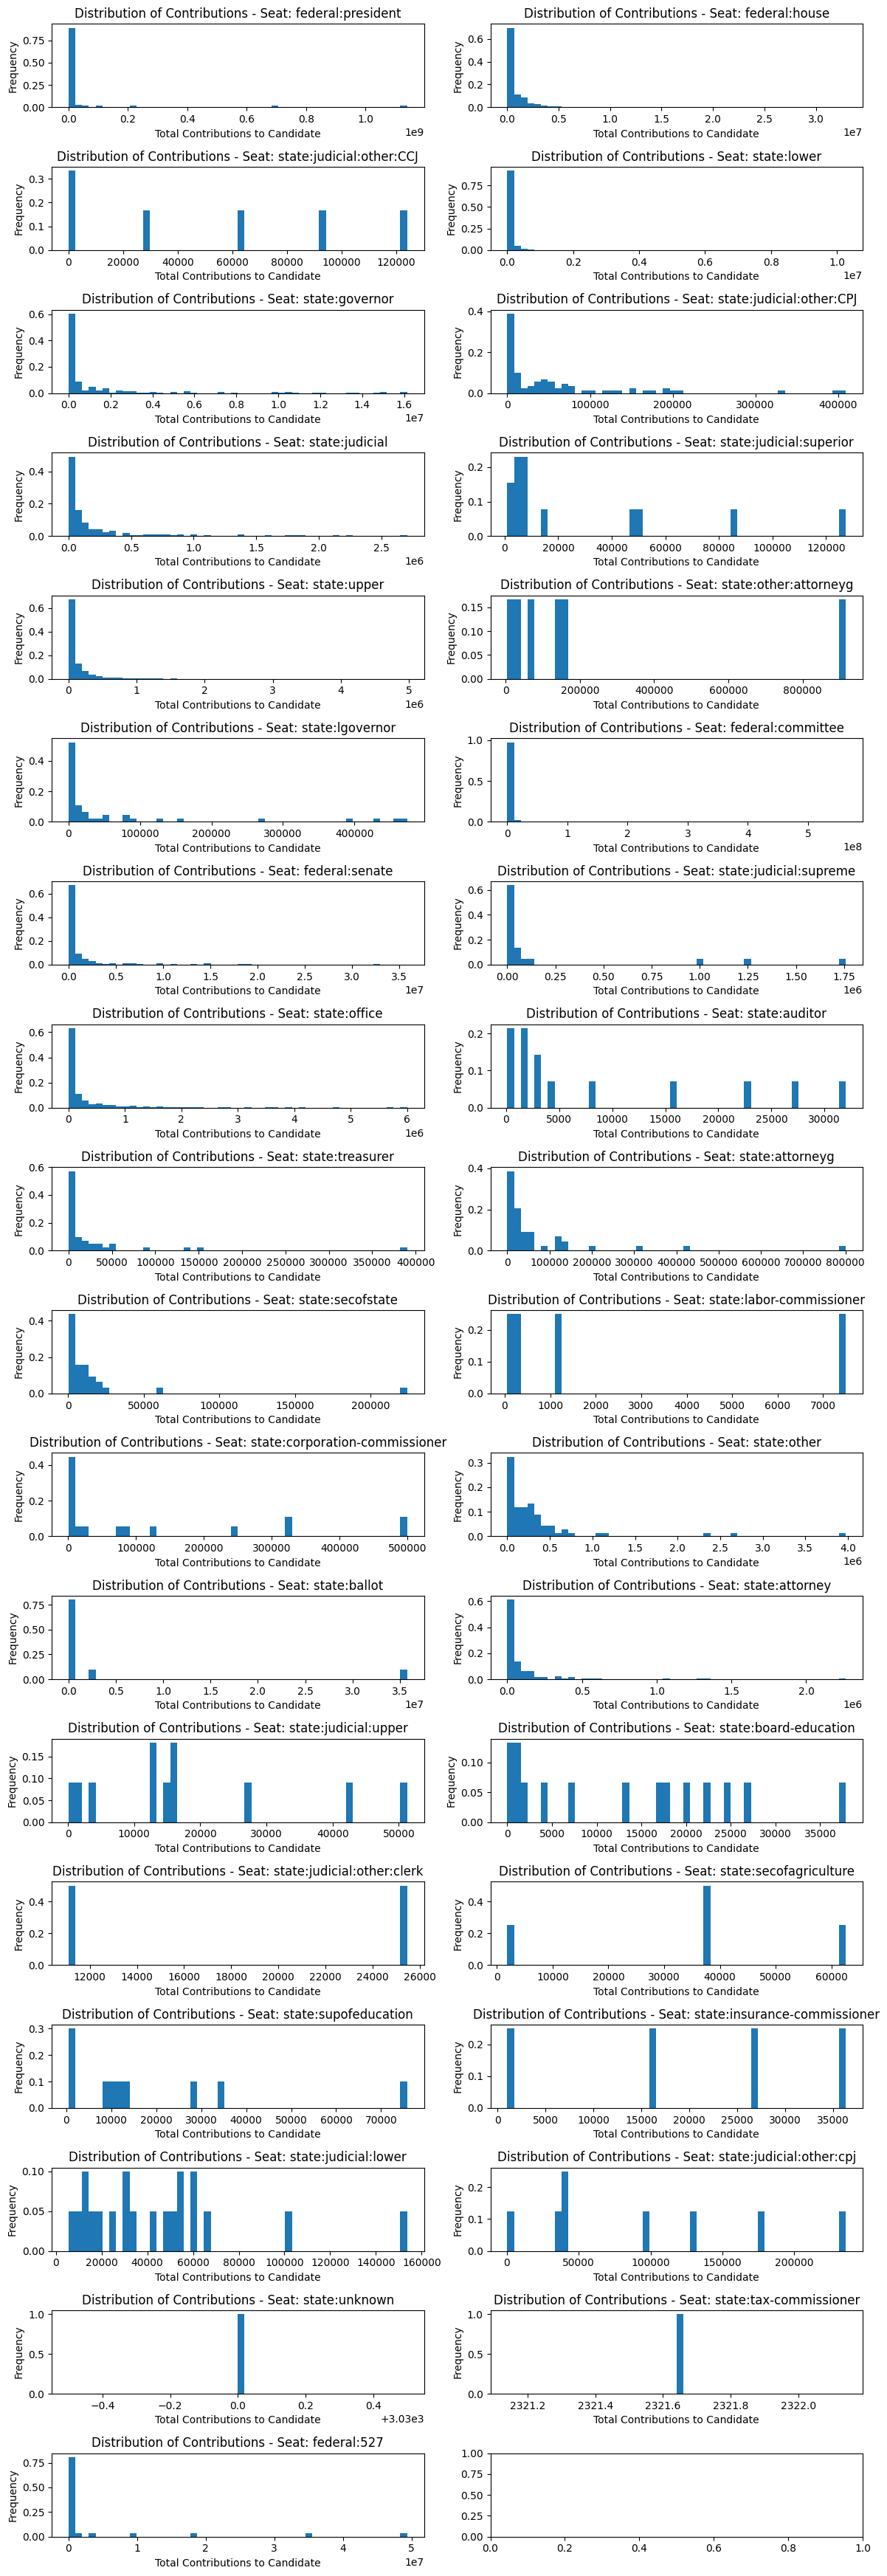

In [110]:
# Plot distribution of contributions by candidate
# Plot distribution of contributions by candidate as frequency plot, split by election.type
import matplotlib.pyplot as plt

# Get unique seat types
seat_types = contrib_by_candidate['seat'].dropna().unique()
seat_types = [s for s in seat_types if 'federal' in s or ('state' in s and 'committee' not in s)]

# Create subplots for each seat type
fig, axes = plt.subplots(len(seat_types)//2 + len(seat_types)%2, 2, figsize=(12, len(seat_types)))

# Handle case where there's only one seat type
if len(seat_types) == 1:
    axes = [axes]

for idx, seat_type in enumerate(seat_types):
    row, col = idx // 2, idx % 2
    data = contrib_by_candidate[contrib_by_candidate['seat'] == seat_type]['amount']
    axes[row, col].hist(data, bins=50, log=False, weights=np.ones(len(data)) / len(data))
    axes[row, col].set_xlabel('Total Contributions to Candidate')
    axes[row, col].set_ylabel('Frequency')
    axes[row, col].set_title(f'Distribution of Contributions - Seat: {seat_type}')

plt.tight_layout()
plt.show()

In [111]:
# For contrib_2008, get all rows where a md_donor is identified (cfdb_donor_id in identified_md_donors)
contrib_2008_md_donors = contrib_2008[contrib_2008['bonica.cid'].isin(identified_md_donors)]

# Drop rows with negative or NaN contribution amounts
contrib_2008_md_donors = contrib_2008_md_donors[contrib_2008_md_donors['amount'] > 0].dropna(subset=['amount'])

In [116]:
# Group merged_2008 by bonica.rid and sum amount to get total contributions per candidate by physician donors
candidate_donations_from_physicians = contrib_2008_md_donors.groupby('bonica.rid')['amount'].sum().reset_index()
candidate_donations_from_physicians.columns = ['bonica.rid', 'phys_amount']

print(f"Found {len(candidate_donations_from_physicians)} unique candidates with contributions from physicians.")

Found 11519 unique candidates with contributions from physicians.


In [117]:
# Merge with cand_contrib_rid to get total contributions from physicians and all donors for each candidate
cand_contrib_rid_with_physicians = pd.merge(candidate_donations_from_physicians, cand_contrib_rid, left_on='bonica.rid', right_on='bonica.rid', how='right')

# Convert NaN values in total_amount_from_physicians to 0 (candidates with no contributions from physicians)
cand_contrib_rid_with_physicians['phys_amount'] = cand_contrib_rid_with_physicians['phys_amount'].fillna(0)

print(f"After merging, found {len(cand_contrib_rid_with_physicians)} unique candidates with both physician and total contribution data.")

# Compute share of contributions from physicians for each candidate
cand_contrib_rid_with_physicians['phys_share'] = cand_contrib_rid_with_physicians['phys_amount'] / cand_contrib_rid_with_physicians['amount']

After merging, found 51466 unique candidates with both physician and total contribution data.


In [118]:
cand_contrib_rid_with_physicians

,bonica.rid,phys_amount,amount,phys_share
0,203002008,0.0,1000.00,0.00000
1,C000034182008,0.0,1000.00,0.00000
2,C000106032008,0.0,200.00,0.00000
3,C001041092008,0.0,40.00,0.00000
4,C003322962008,0.0,35.00,0.00000
...,...,...,...,...
51461,comm9999035,0.0,1855.38,0.00000
51462,comm9999064,520.0,565243.77,0.00092
51463,comm9999606,0.0,6120.00,0.00000
51464,lobb10000241,0.0,1000.00,0.00000


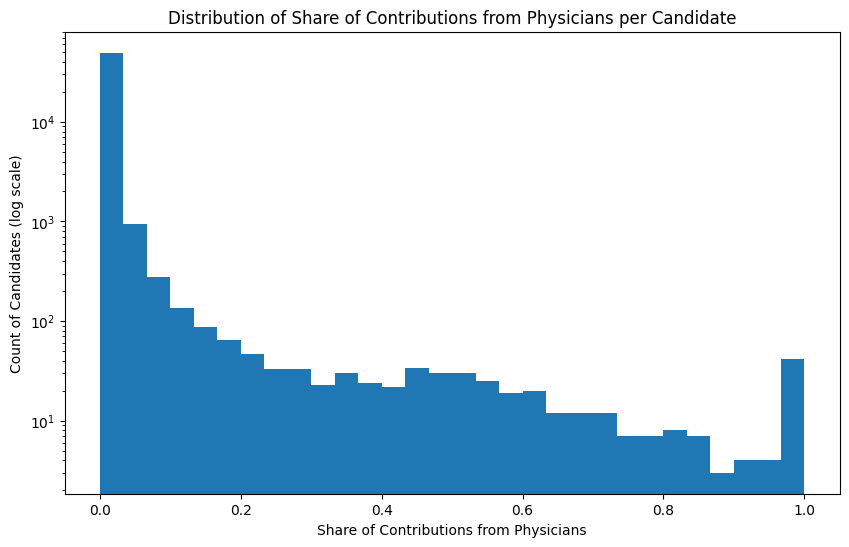

In [120]:

# Plot share of contributions from physicians for each candidate
plt.figure(figsize=(10, 6))
plt.hist(cand_contrib_rid_with_physicians['phys_share'], bins=30, log=True)
plt.title('Distribution of Share of Contributions from Physicians per Candidate')
plt.xlabel('Share of Contributions from Physicians')
plt.ylabel('Count of Candidates (log scale)')
plt.show() 

In [142]:
# Merge in candidate information from contrib_by_candidate
phys_contrib_with_info = pd.merge(cand_contrib_rid_with_physicians, contrib_by_candidate[['bonica.rid', 'recipient.party', 'recipient.state','recipient.type', 'seat', 'candidate.cfscore']], on='bonica.rid', how='left')
phys_contrib_with_info.dropna(subset=['recipient.party', 'recipient.state', 'seat', 'candidate.cfscore'], how='all', inplace=True)
phys_contrib_with_info

,bonica.rid,phys_amount,amount,phys_share,recipient.party,recipient.state,recipient.type,seat,candidate.cfscore
7,cand10,0.0,19500.00,0.000000,200.0,00,CAND,federal:president,0.802
8,cand1000,7135.0,1651396.37,0.004321,100.0,NY,CAND,federal:house,-0.681
33,cand10000191,250.0,88850.00,0.002814,100.0,PA,CAND,local:council,-0.690
42,cand10000203,0.0,28025.00,0.000000,100.0,PA,CAND,local:judicial,-0.671
43,cand10000203,0.0,28025.00,0.000000,100.0,PA,CAND,local:judicial:municipal,-0.671
...,...,...,...,...,...,...,...,...,...
53182,comm9995169,0.0,22625.00,0.000000,328.0,CA,COMM,state:committee,-0.753
53275,comm9995325,4000.0,1261506.35,0.003171,100.0,CA,CAND,state:lower,-0.724
53276,comm9995325,4000.0,1261506.35,0.003171,100.0,CA,CAND,state:other,-0.724
53277,comm9995325,4000.0,1261506.35,0.003171,100.0,CA,COMM,state:committee,-0.724


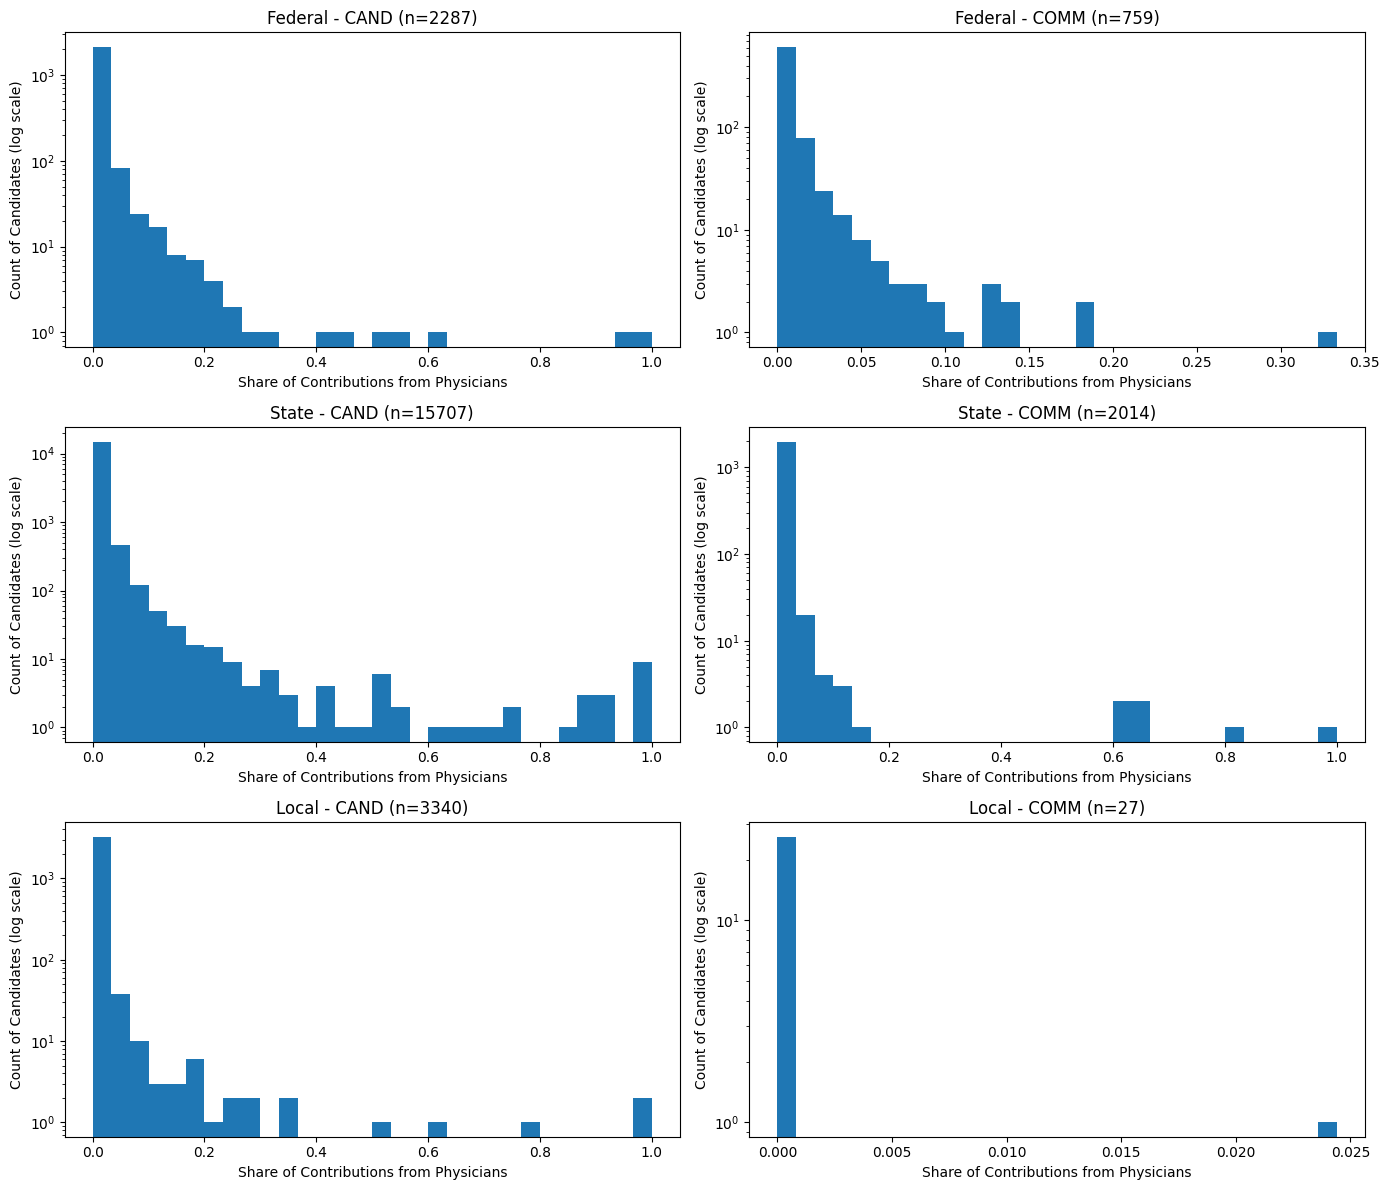

In [143]:
# Plot histogram, separate into two columns: CAND vs COMM, and three rows: federal, state, local
fig, axes = plt.subplots(3, 2, figsize=(14, 12))

levels = ['federal', 'state', 'local']
rec_types = ['CAND', 'COMM']

for row_idx, level in enumerate(levels):
    for col_idx, rtype in enumerate(rec_types):
        mask = (phys_contrib_with_info['seat'].str.contains(level, na=False)) & \
               (phys_contrib_with_info['recipient.type'] == rtype) if rtype == 'CAND' else \
               (phys_contrib_with_info['seat'].str.contains(level, na=False)) & \
               (phys_contrib_with_info['recipient.type'] != 'CAND')
        subset_data = phys_contrib_with_info[mask]['phys_share']
        axes[row_idx, col_idx].hist(subset_data, bins=30, log=True)
        axes[row_idx, col_idx].set_title(f'{level.capitalize()} - {rtype} (n={len(subset_data)})')
        axes[row_idx, col_idx].set_xlabel('Share of Contributions from Physicians')
        axes[row_idx, col_idx].set_ylabel('Count of Candidates (log scale)')

axes[0, 0].set_title(f'Federal - CAND (n={len(phys_contrib_with_info[(phys_contrib_with_info["seat"].str.contains("federal", na=False)) & (phys_contrib_with_info["recipient.type"] == "CAND")])})')
axes[0, 1].set_title(f'Federal - COMM (n={len(phys_contrib_with_info[(phys_contrib_with_info["seat"].str.contains("federal", na=False)) & (phys_contrib_with_info["recipient.type"] != "CAND")])})')

plt.tight_layout()
plt.show()